## Кратко в предыдущих сериях

Советуем перед семинаром освежить в памяти:

* занятие про работу с данными: правила Sanity Check
* занятие про метрики: какие бывают метрики и какие у них свойства
* занятие про визуализации: визуализации в plotly и matplotlib
* прошлое занятие: как смотреть на данные
* прошлое занятие: корреляции и сегментный анализ
* работа с датасетами в `pandas`

# Тема 7. Применение линейной регрессии для исследовательского анализа.

## 0. Цель и задачи

**Цель** — научиться с помощью линейной регрессии определять, от каких показателей зависит целевая переменная.

**Задачи:** 

- разберемся в смысле коэффициентов линейной регрессии
- обсудим границы применимости линейной регрессии
- узнаем, как бороться с ограничениями линейной модели
- разберемся, как можно использовать результаты линейной регрессии для улучшения продукта
- познакомимся с логистической регрессией и применим ее на практике

## 1. Линейная регрессия: теория

### 1.1. Линейная регрессия: постановка задачи

### Вопрос в зал: что такое линейная регрессия?

<br>
<details>
<br>

Линейная регрессия — это метод моделирования зависимостей между целевой переменной и набором независимых переменных (признаков) на основе линейной модели.
    
</details>

Ее можно представить в векторном виде: $Y = X\beta + \varepsilon,$ где 
- $Y = (Y_1, \ldots, Y_n)$ — выборка целевой переменной,
- $X = \begin{pmatrix}
    X_{11} & \ldots & X_{1d} \\
    & \ldots \\  
    X_{n1} & \ldots & X_{nd}
\end{pmatrix}$ — набор из $d$ выборок независимых переменных,
- $\beta = (\beta_1, \ldots, \beta_d)$ — подбираемые параметры модели,
- $\varepsilon = (\varepsilon_1, \ldots, \varepsilon_n)$ — случайные независимые нормальные остатки: $\varepsilon_i \sim \mathcal{N}(0, \sigma^2).$

### 1.2. Линейная регрессия: коэффициенты при параметрах

### Вопрос в зал: какую задачу решают при нахождении параметров линейной регрессии?

<br>
<details>
<br>

Задачу минимизации MSE между истинным значением целевой переменной и ее предсказанием.
    
</details>

Запишем задачу минимизации:
$$f = SSE = ||Y - X\beta||^2_2 = (Y - X\beta)^T(Y - X\beta) = Y^TY - 2\beta^TX^Ty + \beta^TX^TX\beta \rightarrow \min_{\beta}.$$

Для нахождения коэффициентов возьмем производную и приравняем ее к нулю:
$$\frac{\partial f}{\partial \beta} = 2X^TX\beta - 2X^Ty = 0$$
Отсюда $X^TX\beta = X^Ty$ и $\beta = (X^TX)^{-1}X^Ty.$

> Итак, оптимальные коэффициенты в линейной регрессии — это $\hat{\beta} = (X^TX)^{-1}X^Ty.$

### 1.3. Линейная регрессия: значимость коэффициентов

### Вопрос в зал:  допустим, мы посчитали коэффициенты. Как понять, какой признак наиболее сильно влияет на целевую переменную?

<br>
<details>
<br>

Нужно проверять отличие коэффициента при признаке от нуля.
    
</details>

А насколько сильно они отличаются от нуля? Какой коэффициент достаточен: 5, 50 или 500? — Ответ кроется в статистике: мы можем построить доверительный интервал для определения "значимости" коэффициентов.

> **Утверждение:** в предположениях о нормальности и независимости остатков линейной модели для параметра $\beta_j$ можно построить доверительный интервал доверия $1 - \alpha$: $$\left(\hat{\beta_j} - T_{n - d, 1 - \alpha/2} \frac{SSE}{n - d}(X^{-1}X)_{jj}, \hat{\beta_j} + T_{n - d, 1 + \alpha/2} \frac{SSE}{n - d}(X^{-1}X)_{jj}\right),$$ где $T_{n - d, 1 - \alpha/2}$ — это $1 - \alpha/2$-квантиль распределения Стьюдента с $n - d$ степенями свободы (при большом $n - d$ можно считать приблизительно нормальным распределением).

**Вывод:** если доверительный интервал из утверждения содержит 0, то коэффициент при признаке $j$ незначим, значит, нет значимого влияния признака $j$ на целевую переменную.

## 2. Линейная регрессия в библиотеке `statsmodels`

In [1023]:
import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns
sns.set(style='darkgrid', font_scale=1.3, palette='Set2')

import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse, mean_absolute_percentage_error as mape
from sklearn.metrics import roc_auc_score, roc_curve

### 2.1. Знакомство с датасетом и его предобработка


#### Бизнес-кейс: "Выбор района и типа домов для застройки"

**Контекст:**
Строительная компания планирует инвестировать в строительство жилых домов в King County (Сиэтл и окрестности). У компании есть ограниченный бюджет и несколько альтернативных стратегий:

* строить большие дома с большим количеством комнат
* строить дома поменьше, но с ориентацией на вид на воду/хорошее качество отделки
* строить в конкретных районах (по zipcodes), где ожидается высокий спрос

**Цель компании:**
Определить оптимальный район и характеристики будущих домов, которые максимизируют цену продажи

---

**Формулировка задачи в терминах данных**

* Использовать `zipcode`, `lat`, `long` для поиска районов с наибольшим приростом средней цены за м²
* Построить модель зависимости цены (`price`) от признаков `sqft_living`, `bedrooms`, `bathrooms`, `floors`, `grade`, `waterfront`
* Оценить вклад каждого признака в цену
* Сравнить влияние улучшений (`waterfront`, `view`, `grade`, `renovation`) на цену продажи

**Небольшое описание данных: King County Housing Dataset**

* **Регион:** округ Кинг (King County), штат Вашингтон, США, включая Сиэтл.
* **Период:** продажи жилой недвижимости с **мая 2014 по май 2015 года**.
* **Размерность:** **21 613 записей** (каждая строка — это одна сделка купли-продажи).
* **Целевая переменная:** `price` — цена продажи дома (в долларах США).

---

**Структура данных**

1. **Основные поля:**

   * `id` — уникальный идентификатор сделки.
   * `date` — дата продажи.
   * `price` — стоимость продажи (таргет для моделей).

2. **Характеристики объекта:**

   * `bedrooms` — количество спален.
   * `bathrooms` — количество ванных комнат (включая половины).
   * `sqft_living` — жилая площадь (в квадратных футах).
   * `sqft_lot` — площадь участка.

3. **Структурные особенности:**

   * `floors` — число этажей.
   * `waterfront` — вид на набережную (бинарный).
   * `view` — наличие/качество вида из дома (категория).
   * `condition` — общее состояние дома (категория).
   * `grade` — качественная оценка уровня строительства и дизайна.

4. **Вспомогательные размеры:**

   * `sqft_above` — площадь над землёй.
   * `sqft_basement` — площадь подвала.

5. **Временные параметры:**

   * `yr_built` — год постройки.
   * `yr_renovated` — год последнего ремонта (0 — если ремонта не было).

6. **Геолокация:**

   * `zipcode` — почтовый индекс.
   * `lat`, `long` — широта и долгота.

7. **Дополнительные размеры (2015):**

   * `sqft_living15` — жилая площадь соседних домов в 2015 году (как прокси средней площади в районе).
   * `sqft_lot15` — средний размер участка в районе в 2015 году.
   
   ### Вопрос в зал: какие бывают типы переменных? Как с ними работать?

<br>
<details>
<br>

- **непрерывные** — переменные с непрерывной областью значений. Можно просто оставить переменную как есть, или "стандартизировать", то есть, отобразить в какой-нибудь отрезок (чаще всего или [0, 1], или [-1, 1])
- **дискретные** — переменные с дискретной областью значений. Можно просто оставить переменную как есть
- **порядковые** — категории с порядком, но без точной шкалы (то есть, разница между 1 и 2 может быть не равна разнице между 2 и 3). Можно оставить, как есть, если считаем, что ближе к дискретным, а можем — сделать One-Hot, если считаем, что ближе к категориальным
- **категориальные** — отражают какие-то категории, не имеют порятка. Чаще всего делают One-Hot-кодирование, то есть, каждой категории сопоставляют вектор из нулей, кроме одной позиции, соответствующей номеру этой категории
    
</details>

**Переменные и их типы**


| Колонка            | Описание                                               | Тип переменной                                                                                                  |
| ------------------ | ------------------------------------------------------ | --------------------------------------------------------------------------------------------------------------- |
| **id**             | Уникальный идентификатор сделки                        | категориальная (номинальная, surrogate ID)                                                                      |
| **date**           | Дата продажи                                           | категориальная (временная метка, можно преобразовать)                                                           |
| **price**          | Цена продажи дома (таргет)                             | непрерывная                                                                                                     |
| **bedrooms**       | Количество спален                                      | дискретная                                                                                                      |
| **bathrooms**      | Количество ванных комнат (может быть 1.5, 2.25 и т.д.) | непрерывная (формально количественная, но часто квазидискретная)                                                |
| **sqft\_living**   | Жилая площадь (фут²)                                   | непрерывная                                                                                                     |
| **sqft\_lot**      | Площадь участка (фут²)                                 | непрерывная                                                                                                     |
| **floors**         | Количество этажей                                      | дискретная (иногда записано как 1.5 → можно трактовать как порядковая/дискретная)                               |
| **waterfront**     | Наличие вида на набережную (0/1)                       | категориальная (бинарная)                                                                                       |
| **view**           | Оценка вида (0–4)                                      | порядковая                                                                                                      |
| **condition**      | Общее состояние дома (1–5)                             | порядковая                                                                                                      |
| **grade**          | Класс строительства и дизайна (1–13)                   | порядковая                                                                                                      |
| **sqft\_above**    | Площадь над уровнем земли                              | непрерывная                                                                                                     |
| **sqft\_basement** | Площадь подвала                                        | непрерывная                                                                                                     |
| **yr\_built**      | Год постройки                                          | дискретная (но с временной природой)                                                                            |
| **yr\_renovated**  | Год последнего ремонта (0, если не было)               | дискретная (с особыми значениями; можно перевести в категориальная {не ремонтировался, ремонтировался в год Х}) |
| **zipcode**        | Почтовый индекс                                        | категориальная (номинальная, географический код)                                                                |
| **lat**            | Широта                                                 | непрерывная                                                                                                     |
| **long**           | Долгота                                                | непрерывная                                                                                                     |
| **sqft\_living15** | Средняя жилая площадь соседних домов (фут²)            | непрерывная                                                                                                     |
| **sqft\_lot15**    | Средняя площадь участка соседних домов (фут²)          | непрерывная                                                                                                     |

In [1024]:
data = pd.read_csv('kc_house_data.csv')
data

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530.0,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310.0,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020.0,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600.0,0,2004,0,98027,47.5345,-122.069,1410,1287


Посмотрим на типы данных и пропуски

In [1025]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

Что видим:
- пропусков почти нет: всего 2 пропуска в колонке `sqft_above`
- колонку с датой стоит преобразовать в тип с датами
- некоторые колонки стоит преобразовать в другой тип: `zipcode` обозначает не числовую переменную, а категориальную, и отражает почтовый индекс района
- в колонку `yr_renovated` можно добавить год постройки, если реновации не было

Посмотрим на соотношение колонок `sqft_above`, `sqft_living` и `sqft_basement`

In [1026]:
(data['sqft_living'] - data['sqft_basement'] == data['sqft_above']).sum()

21611

При этом везде, где нет пропусков, колонка `sqft_above` — это разность между `sqft_living` и `sqft_basement`

### Вопрос в зал: стоит ли оставлять такие колонки? Почему?

<br>
<details>
<br>

Нет, из-за мультиколлинеарности признаков
    
</details>

Теперь посмотрим, сколько значений принимает `zipcode`

In [1027]:
len(data['zipcode'].unique())

70

In [1028]:
data['zipcode'].value_counts()

zipcode
98103    602
98038    590
98115    583
98052    574
98117    553
        ... 
98102    105
98010    100
98024     81
98148     57
98039     50
Name: count, Length: 70, dtype: int64

Довольно много значений. Для таких случаев может быть полезен `mean_encoding` — это способ кодирования категориальных переменных, при котором каждой категории присваивается численное значение, равное среднему значению целевой переменной для этой категории.

Так как у нас данные с выбросами, то можно попробовать использовать медиану, а не среднее

> **Замечание:** при использовании `mean_encoding` велик риск переобучения модели, поэтому лучше использовать `holdout_mean_encoding`, который использует для кодирования одну часть выборки, а применяется на другой 

Посмотрим, в скольких случаях дом не реставрировался

In [1029]:
(data['yr_renovated'] == 0).sum()

20699

В 95% случаев дом не реставрировался. В этом случае можно заменить признак `yr_renovated` на `was_renovated`, означающий факт реставрации дома. Также можно изменить признак `yr_built` на более интерпретируемый `yrs_from_built`, то есть, сколько лет прошло с постройки дома

**Итого:** 
- колонки `date`, `yr_built` и `yr_renovated` мы заменим на новые
- выкинем колонки `id` и `sqft_above`
- выделим колонку с таргетом и с признаками
- оставим 10% на тест, чтобы посмотреть на факт переобучения
- на `data_train` применим `holdout_mean_encoding` на 20% отложенной выборки

Предобработаем колонки

In [1030]:
# записываем нужные типы колонок
date_columns = ['date']
cat_columns = []
drop_columns = ['id', 'sqft_above']
target_column = 'price'
num_columns = list(set(data.columns) - set(date_columns) - set(target_column) - set(drop_columns))

# обрабатываем колонки с датой
for col in date_columns:
    data[col] = pd.to_datetime(data[col])
    
# заменяем колонки date, yr_built и yr_renovated на новые
data['days_from_last_deal'] = (data['date'].max() - data['date']).dt.days
data['yrs_from_built'] = 2015 - data['yr_built']
data['was_renovated'] = (data['yr_renovated'] > 0).astype(int)

# обрабатываем категориальные колонки (тут их нет, но код для их преобразования приведен)
data[cat_columns] = data[cat_columns].astype('O')
data = pd.get_dummies(data, drop_first=True)

# выкидываем ненужные колонки
data.drop(columns=drop_columns + ['date', 'yr_built', 'yr_renovated'], inplace=True)

# делим на трейн и тест
data_train, data_test = train_test_split(data, test_size=0.1, random_state=42)
data_train

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,days_from_last_deal,yrs_from_built,was_renovated
6181,289950.0,4,1.75,2090,7416,1.0,0,0,4,7,1040,98031,47.4107,-122.179,1710,7527,166,45,0
4688,465000.0,3,2.50,1450,5175,1.0,0,0,3,8,420,98133,47.7082,-122.338,1740,9250,176,20,0
1703,617000.0,3,1.75,3020,360241,2.0,0,0,3,8,0,98092,47.2662,-122.088,1890,209959,170,23,0
21200,720000.0,3,1.75,1370,1990,3.0,0,0,3,9,0,98102,47.6434,-122.324,1730,1990,92,1,0
18874,381000.0,3,1.75,1330,7216,1.0,0,0,3,7,0,98034,47.7199,-122.180,1500,8000,289,46,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,378000.0,3,1.50,1000,6914,1.0,0,0,3,7,0,98125,47.7144,-122.319,1000,6947,195,68,0
21575,399950.0,3,2.50,3087,5002,2.0,0,0,3,8,0,98023,47.2974,-122.349,2927,5183,197,1,0
5390,575000.0,3,2.50,2120,4780,2.0,0,0,3,7,0,98053,47.6810,-122.032,1690,2650,239,11,0
860,245000.0,1,0.75,380,15000,1.0,0,0,3,5,0,98168,47.4810,-122.323,1170,15000,341,52,0


In [1031]:
def holdout_mean_encoding(df, cat_col, target_col, test_size=0.8, random_state=42, 
                          df_delayed=None, df_holdout=None):
    """
    Holdout Target Encoding:
    - Разделяем данные на две части
    - На первой считаем средние target по категориям
    - На второй применяем эти средние
    """
    if df_delayed is None:
        # Разделение на holdout и train
        df_delayed, df_holdout = train_test_split(df, test_size=test_size, random_state=random_state)

    # Средние значения по train
    means = df_delayed.groupby(cat_col)[target_col].median()

    # Кодирование
    df_holdout[cat_col + "_enc"] = df_holdout[cat_col].map(means)

    return df_delayed, df_holdout, means

In [1032]:
# Применяем encoding
data_delayed, data_train, mapping = holdout_mean_encoding(data_train, "zipcode", "price")
X_train = data_train.drop(columns=[target_column])
X_test = data_test.drop(columns=[target_column])
Y_train = data_train[target_column]
Y_test = data_test[target_column]
features = data_train.drop(columns=[target_column, 'zipcode']).columns

Наконец, мы готовы к обучению линейной регрессии

### 2.2. Немного о линейной регрессии в statsmodels

Приведем краткую документацию `statsmodels.formula.api.ols`:

**Что это такое?**

Функция `ols` из модуля `statsmodels.formula.api` позволяет задавать и строить линейную регрессию, используя формулу в стиле R и объекты типа DataFrame

**Сигнатура:**

```python
ols(formula, data, subset=None, drop_cols=None, *args, **kwargs)
```

* **formula** — строка или объект `Formula`, описывающий модель в виде `'target ~ feature_1 + ...  + feature_d'`(например, `'y ~ x1 + x2'`)
* **data** — pandas DataFrame, из которого берутся переменные
* **subset** — массив бинарных значений, индексов или целых чисел — для подмножества строк данных, используемого в модели
* **drop\_cols** — список колонок, которые нужно исключить из матрицы признаков (не применяется к категориальным переменным)
* **\*args, \*\*kwargs** — дополнительные аргументы, передаваемые в конструктор модели

**Возвращаемое значение:**

Функция возвращает объект **Model**, готовый к обучению:

```python
model = smf.ols(formula='y ~ x1 + x2', data=df)
results = model.fit()
```

Здесь `model` — объект модели, создание которого осуществляется на основе формулы и данных 

---

**Метод `.fit()`:**

После создания модели необходимо вызвать метод `.fit()`:

```python
results = model.fit(method='pinv', cov_type='nonrobust', cov_kwds=None, use_t=None, **kwargs)
```

* **method** — способ решения задачи наименьших квадратов: `'pinv'` (псевдообратная матрица Мура-Пенроуза) или `'qr'` (QR-разложение)
* **cov\_type** — тип оценки ковариационной матрицы
* **cov\_kwds** — дополнительные параметры для оценки ковариации
* **use\_t** — флаг: использовать t-распределение при вычислении p-значений (зависит от `cov_type`)
* **\*\*kwargs** — могут содержать данные, используемые при формульном интерфейсе

Метод возвращает объект `RegressionResults` с результатами: коэффициентами, стандартными ошибками, t-статистиками, p-значениями и др.

**Что ещё важно знать**

- *Формула R-стиля:* поддерживаются взаимодействия (`x1 * x2`), произведения (`x1:x2`), исключение переменных (`- x3`) и функции (`np.log(x1)`)

- *Категориальные переменные:* при использовании формул категориальные переменные автоматически кодируются как one-hot
- Добавление константы: при использовании формульного интерфейса (`formula.api.ols`) константа добавляется автоматически, если только не задано обратное в формуле


**Итого:**

| Составляющий             | Описание                                                                       |
| ------------------------ | ------------------------------------------------------------------------------ |
| `formula` + `data`       | Задаёт модель с использованием формулы и данных                                |
| `subset`, `drop_cols`    | Контроль подмножества данных и исключение переменных                           |
| `.fit(...)`              | Обучение модели, выбор метода решения, оценка ковариации                       |
| Формульный интерфейс     | Простой синтаксис, автоматическая константа, кодирование категорий             |
| `.summary()` (после fit) | Вывод статистик модели: R², AIC, BIC, коэффициенты и статистическая значимость |


**Как читать результаты `.summary()`:**



1. Заголовок и основные параметры модели

    В начале выводятся настройки модели:

    * **Dependent Variable** — зависимая переменная, то, что вы пытаетесь предсказать
    * **Model/Method** — тип модели (обычно OLS, «Ordinary Least Squares») и способ её оценки.
    * **No. Observations** — число наблюдений (N)
    * **Df Residuals** — степени свободы остатка, рассчитываются как N минус число предикторов (включая константу)
    * **Df Model** — число используемых предикторов (без учёта константы)
    * **Covariance Type** — тип оценки ковариации (например, `nonrobust`)

    Также могут присутствовать:

    * **Log-Likelihood** — логарифм правдоподобия модели,
    * **AIC / BIC** — информационные критерии Акаике и Байеса, служат для сравнения моделей с учётом сложности: чем ниже — тем лучше

2. Общая статистика модели

    * **R-squared** — доля дисперсии зависимой переменной, объяснённая моделью (0–1). Чем больше — тем лучше подгонка
    * **Adj. R-squared** — скорректированный R², учитывает число переменных, корректирует за добавление незначимых факторов
    * **F-statistic** и **Prob (F-statistic)** — тест значимости всей регрессии: проверяется гипотеза «все коэффициенты (кроме константы) равны нулю». Низкое `Prob` (обычно < 0.05) говорит, что модель значима

3. Таблица коэффициентов

    Для каждого предиктора (и константы) выводятся:

    * **coef** — оценённое значение коэффициента. Изменение зависимой переменной при изменении предиктора на один «единицу» (в его шкале). Вычисляется как $\beta = (X^T X)^{-1}X^T y$
    * **std err** — стандартная ошибка оценки, показывает надёжность коэффициента
    * **t** и **P>|t|** — t-статистика и p-значение для проверки гипотезы, что коэффициент равен нулю. Малое p-значение (обычно < 0.05) говорит о значимости признака
    * **\[0.025, 0.975\]** — 95 \% доверительный интервал для истинного значения коэффициента. Тот самый доверительный интервал из утверждения

4. Диагностика предположений модели

    В конце отчёта находятся дополнительные статистики, оценивающие пригодность модели:

    * **Omnibus** и **Prob(Omnibus)** — тест на нормальность остатков. Высокое p-значение (> 0.05) означает, что нет оснований отвергнуть нормальность
    * **Jarque-Bera (JB)** и **Prob(JB)** — ещё один тест на нормальность через асимметрию и эксцесс
    * **Skew** — асимметрия распределения остатков; **Kurtosis** — мера «тяжёлых хвостов» (3 — нормальное распределение)
    * **Durbin-Watson** — тест автокорреляции остатков (зависимость от времени). Значения около 2 означают отсутствие автокорреляции; ближе к 0 — положительную; к 4 — отрицательную
    * **Condition No.** — число обусловленности: показатель мультиколлинеарности. Значения выше \~30 могут свидетельствовать о проблемах с корреляцией предикторов

Краткий пазл: “Что говорит результирующая таблица?”

| Блок                    | Что важно смотреть                                                                   |
| ----------------------- | ------------------------------------------------------------------------------------ |
| **1. Настройки модели** | Вид модели, число данных, df.                                                        |
| **2. Общие метрики**    | R², скорректированный R², F-test — общее качество модели.                            |
| **3. Коэффициенты**     | Значения coef, их значимость (p-value), доверительные интервалы.                     |
| **4. Диагностика**      | Проверка ключевых предположений: нормальность, автокорреляция, мультиколлинеарность. |

### 2.3. Обучение линейной регрессии

In [1033]:
linear = smf.ols(f"{target_column} ~{' + '.join(features)}", data_train)
result = linear.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     3035.
Date:                Sun, 24 Aug 2025   Prob (F-statistic):               0.00
Time:                        00:17:55   Log-Likelihood:            -2.0956e+05
No. Observations:               15561   AIC:                         4.192e+05
Df Residuals:                   15542   BIC:                         4.193e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -3.669e+07   1.54e+06    -23.893      0.000   -3.97e+07   -3.37e+07
bedrooms            -2.808e+04   1867.532    -15.036      0.000   -3.17e+04   -2.44e+04
bathrooms            3.898e+04   3258.057     11.965      0.000    3.26e+04    4.54e+04
sqft_living           197.4411      3.680     53.657      0.000     190.228     204.654
sqft_lot                0.1899      0.050      3.829      0.000       0.093       0.287
floors              -1.283e+04   3574.595     -3.590      0.000   -1.98e+04   -5825.821
waterfront            5.16e+05    1.8e+04     28.700      0.000    4.81e+05    5.51e+05
view                 5.791e+04   2123.752     27.266      0.000    5.37e+04    6.21e+04
condition            1.861e+04   2347.752      7.926      0.000     1.4e+04    2.32e+04
grade                5.834e+04   2205.890     26.446      0.000     5.4e+04    6.27e+04
sqft_basement         -62.3375      4.389    -14.202      0.000     -70.941     -53.734
lat                  1.133e+05    1.2e+04      9.436      0.000    8.98e+04    1.37e+05
long                -2.502e+05   1.21e+04    -20.704      0.000   -2.74e+05   -2.27e+05
sqft_living15         -18.5451      3.488     -5.317      0.000     -25.381     -11.709
sqft_lot15             -0.1456      0.074     -1.977      0.048      -0.290      -0.001
days_from_last_deal  -112.9979     12.182     -9.276      0.000    -136.876     -89.120
yrs_from_built       1627.3605     72.324     22.501      0.000    1485.597    1769.124
was_renovated        2.724e+04   7334.956      3.714      0.000    1.29e+04    4.16e+04
zipcode_enc             0.7361      0.009     78.807      0.000       0.718       0.754
==============================================================================
Omnibus:                    15976.533   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3758081.898
Skew:                           4.613   Prob(JB):                         0.00
Kurtosis:                      78.571   Cond. No.                     5.83e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.83e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Практика: давайте по summary сделаем вывод по модели

<br>
<details>
<br>

1. *Качество модели:*

    * **R-squared: 0.698**
      Модель объясняет \~70% дисперсии цен домов
    * **F-statistic = 2640, Prob(F-statistic) = 0.000**
      Модель в целом статистически значима: хотя бы некоторые коэффициенты действительно влияют на цену

2. *Ключевые факторы:* 
    
    * стоимость квартир в районе:* **zipcode_enc: +0.74\$ за 1\$ медианной стоимости квартиры в районе** — основной фактор: ожидаемо, чем дороже квартира в районе, тем дороже и наша квартира
    * площадь дома: **sqft\_living: +200\$ за квадратный фут** — второй основной фактор: чем больше площадь — тем более дорогой дом
    * вид на воду: **waterfront: +516 000\$ за вид** — побережье очень сильно влияет на цену
    * оценка вида: **view: +58 000\$ за 1 пункт** — вид из окна тоже оказывает значимое влияние на цену
    * класс строительства: **grade: +58 000\$ за 1 пункт** — чем выше качество постройки, тем дом дороже
    * возраст дома: **: +1600\$ за 1 год давности** — чем новее дом, тем он дороже
    
3. *Факторы, которые не влияют или мало влияют:* размер участка соседей (`sqft_lot15`) — влияние минимальное
    
4. *Диагностика модели:*

    * **Durbin-Watson: 2.003**
      Остатки не автокоррелированы (то есть, нет зависимости во времени)
    * **Omnibus / Jarque-Bera (p=0.000)**
      Остатки *не нормальны* (распределение асимметричное, с тяжёлыми хвостами: Skew = 3.64, Kurtosis = 49)
      Это говорит о выбросах или сильной асимметрии данных
    * **Cond. No. = 5.83e+08 (очень большое)**
      Есть **сильная мультиколлинеарность** между признаками (например, sqft\_living, sqft\_basement, bedrooms, bathrooms коррелируют). Это делает интерпретацию коэффициентов ненадёжной, хотя предсказательная сила модели может оставаться высокой
    
</details>

> Как мы видим, не все так просто: у модели не нормальные остатки с тяжелыми хвостами, а также есть мультиколлинеарность

1. Для начала попробуем разобраться с мультиколлинеарностью: посмотрим матрицу корреляций

In [1034]:
corr = data_train.select_dtypes(include=np.number).corr().round(2)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="RdBu_r",
    title="Корреляционная матрица",
    width=800,
    height=800
)
fig.update_layout(
    xaxis_title="Признаки",
    yaxis_title="Признаки",
    template="plotly_white"
)
fig.show()

Видим некоторые слабо скоррелированные с таргетом признаки, которые зависимы друг с другом:

- признак `bathrooms`, `bedrooms` и `sqft_living15` сильно скоррелированы с признаком `sqft_living`, при этом влияние на таргет не такое большое
- признаки `sqft_lot15` и `sqft_lot` сильно скоррелированы между собой и не сильно влияют на таргет
- признак `yrs_from_built` имеет очень слабую корреляцию с таргетом, при этом сильно скоррелирован с признаком `sqft_living`

**Итого:** попробуем удалить признаки `bathrooms`, `bedrooms`, `sqft_living15`, `yrs_from_built`, `sqft_lot15` и `sqft_lot`.

2. Далее посмотрим на то, как распределились предсказания в зависимости от таргета. Это поможет нам сделать остатки более нормальными

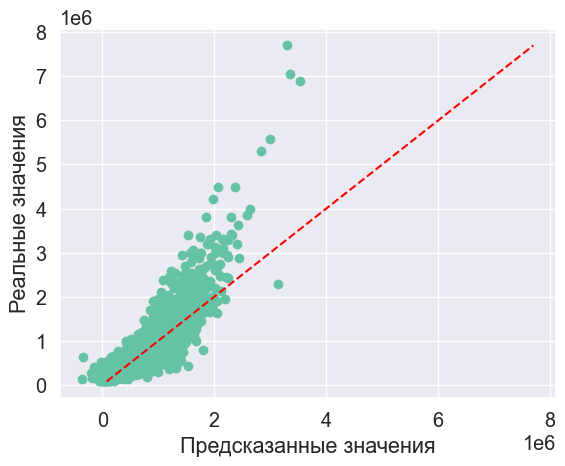

In [1035]:
y_pred = result.predict()

plt.scatter(y_pred, Y_train)
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Реальные значения')
plt.show()

Видно, что квартиры большей стоимости плохо описываются моделью. Посмотрим также на связь реальных значений с важными вещественными признаками

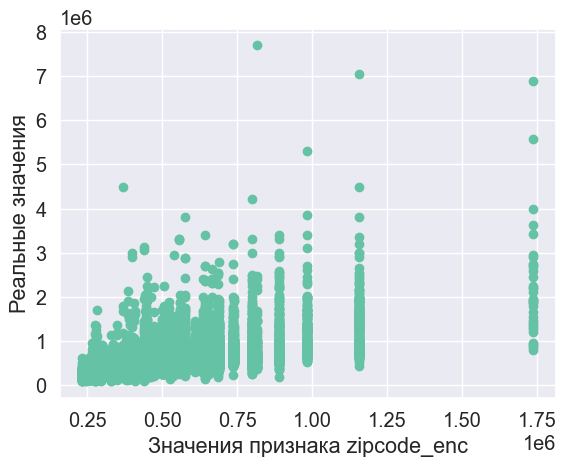

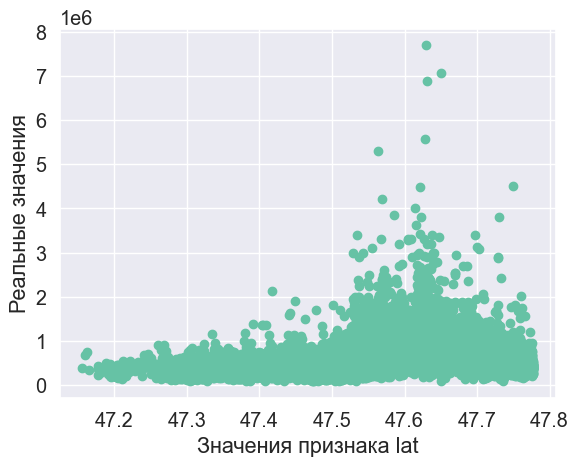

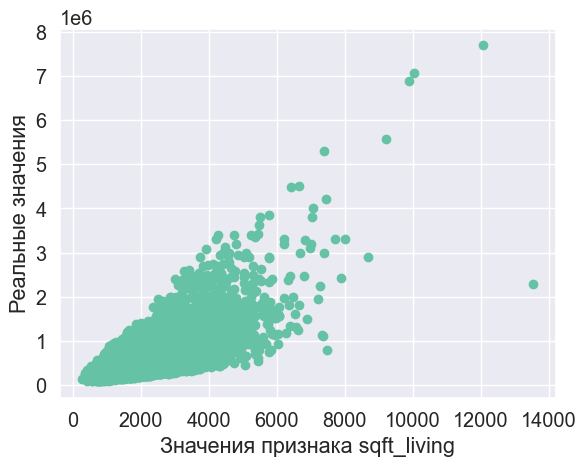

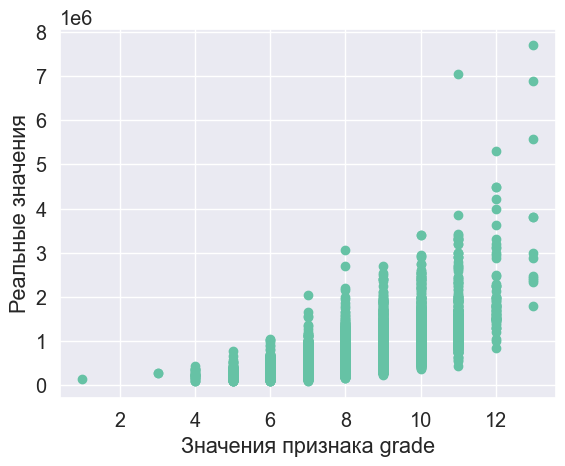

In [1036]:
main_features = ['zipcode_enc', 'lat', 'sqft_living', 'grade']

for feature in main_features:
    
    plt.scatter(X_train[feature], Y_train)
    plt.xlabel(f'Значения признака {feature}')
    plt.ylabel('Реальные значения')
    plt.show()

Посмотрим и на boxplot значений стоимостей

<Axes: ylabel='price'>

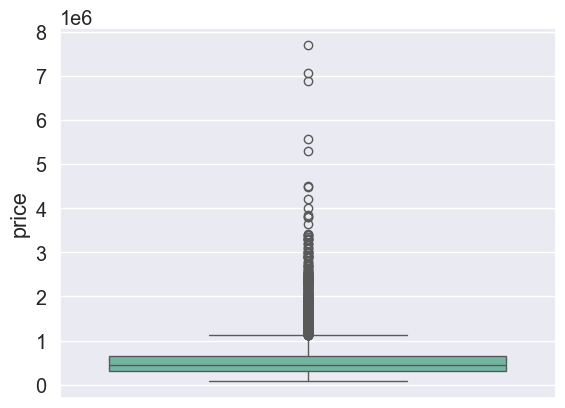

In [1037]:
sns.boxplot(Y_train)

Посмотрим, сколько значений больше 2 млн.\$

In [1038]:
(Y_train > 2e6).sum(), (Y_train > 2e6).mean()

(128, 0.008225692436218752)

- всего менее 1% значений больше 2 миллионов долларов, так что **будем считать эти данные выбросами и не использовать их для выводов касательно остальных элементов**
- как мы отметили выше, у нас есть проблема с неодинаковой дисперсией остатков. Ее можно попробовать решить, **используя устойчивую к выбросам ковариационную матрицу.** Для этого при обучении модели необходимо указать `cov_type='HC3'`

In [1039]:
multicollinear_columns = ['bathrooms', 'bedrooms', 'sqft_living15', 'yrs_from_built', 'sqft_lot15', 'sqft_lot']
data_train.drop(columns=multicollinear_columns, inplace=True)
data_train = data_train[Y_train < 2e6]
data_delayed = data_delayed[data_delayed < 2e6]
data_delayed, data_train, mapping = holdout_mean_encoding(data_train, "zipcode", "price", 
                                                          df_delayed=data_delayed, df_holdout=data_train)
features = data_train.drop(columns=[target_column, 'zipcode']).columns
data_train

,price,sqft_living,floors,waterfront,view,condition,grade,sqft_basement,zipcode,lat,long,days_from_last_deal,was_renovated,zipcode_enc
6493,360000.0,1730,1.0,0,0,5,7,720,98106,47.5304,-122.353,380,0,297000.0
14789,240000.0,1520,1.0,0,0,3,8,0,98023,47.3263,-122.365,274,0,276250.0
4512,312000.0,2280,2.0,0,0,3,8,0,98042,47.3861,-122.096,189,0,288000.0
15776,546000.0,1200,1.0,0,0,4,6,0,98027,47.5321,-122.034,105,0,502000.0
10592,373000.0,1310,1.0,0,0,3,7,0,98034,47.7319,-122.167,265,0,440000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5079,656000.0,2270,3.0,0,0,3,7,450,98052,47.6757,-122.121,77,0,645000.0
12624,435000.0,1600,2.0,0,0,3,7,0,98029,47.5531,-121.996,313,0,610000.0
9190,525000.0,1430,1.5,0,0,4,7,300,98115,47.6942,-122.319,189,0,524000.0
14452,400000.0,1510,1.0,0,0,3,7,0,98034,47.7279,-122.195,166,0,440000.0


In [1040]:
linear = smf.ols(f"{target_column} ~{' + '.join(features)}", data_train)
result = linear.fit(cov_type='HC3')
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.797
Method:                 Least Squares   F-statistic:                     2355.
Date:                Sun, 24 Aug 2025   Prob (F-statistic):               0.00
Time:                        00:17:57   Log-Likelihood:            -2.0341e+05
No. Observations:               15427   AIC:                         4.069e+05
Df Residuals:                   15414   BIC:                         4.070e+05
Df Model:                          12                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            -4.06e+07   1.09e+06    -37.265      0.000   -4.27e+07   -3.85e+07
sqft_living           144.4285      3.010     47.984      0.000     138.529     150.328
floors              -1.073e+04   2534.834     -4.232      0.000   -1.57e+04   -5758.251
waterfront           2.324e+05   3.51e+04      6.619      0.000    1.64e+05    3.01e+05
view                 5.718e+04   2485.097     23.008      0.000    5.23e+04     6.2e+04
condition            3.301e+04   1796.653     18.370      0.000    2.95e+04    3.65e+04
grade                5.275e+04   1992.998     26.467      0.000    4.88e+04    5.67e+04
sqft_basement         -45.2651      4.286    -10.561      0.000     -53.665     -36.865
lat                  1.722e+05   9360.501     18.398      0.000    1.54e+05    1.91e+05
long                -2.603e+05   9063.388    -28.722      0.000   -2.78e+05   -2.43e+05
days_from_last_deal  -102.6854      9.416    -10.905      0.000    -121.141     -84.230
was_renovated        8.119e+04   7493.556     10.835      0.000    6.65e+04    9.59e+04
zipcode_enc             0.7053      0.011     63.630      0.000       0.684       0.727
==============================================================================
Omnibus:                     4757.808   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            29993.572
Skew:                           1.332   Prob(JB):                         0.00
Kurtosis:                       9.290   Cond. No.                     5.01e+08
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 5.01e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

С нормальностью стало получше, а вот с мультиколлинеарностью вопрос не решен

Посмотрим еще раз на связь реальных значений с важными вещественными признаками

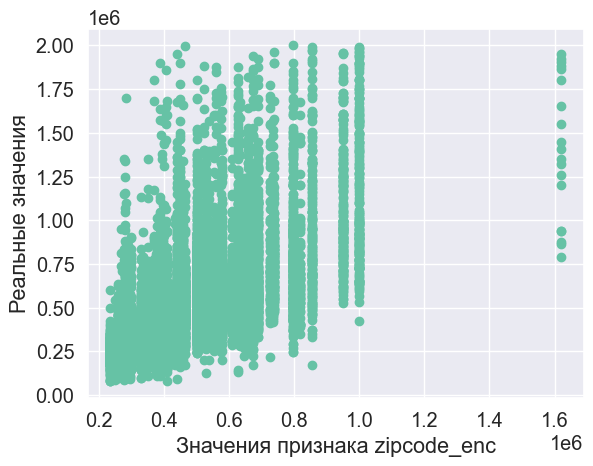

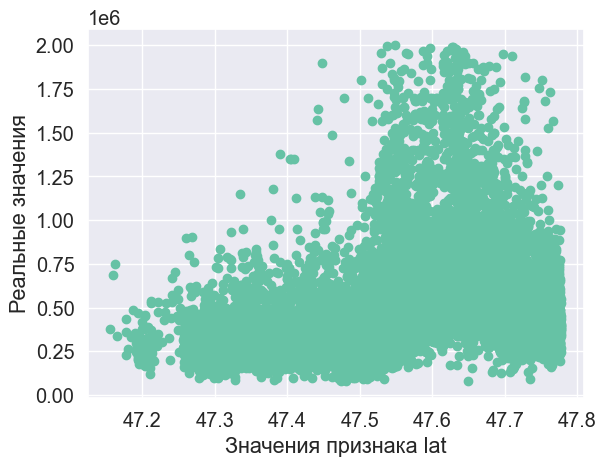

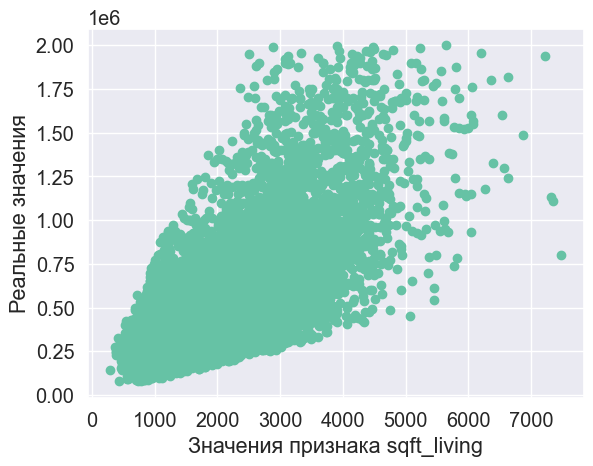

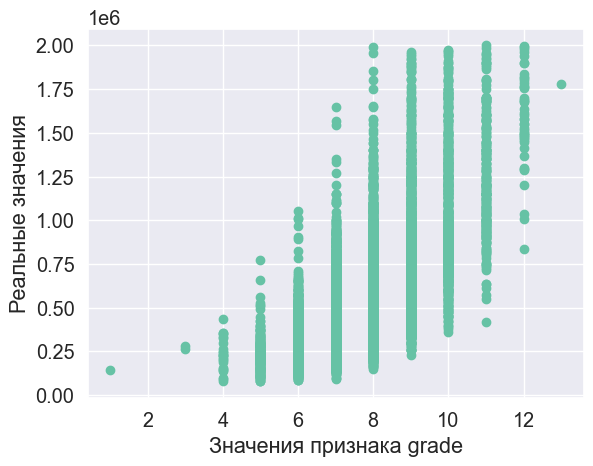

In [1041]:
X_train = data_train.drop(columns=[target_column])
Y_train = data_train[target_column]

for feature in main_features:
    
    plt.scatter(X_train[feature], Y_train)
    plt.xlabel(f'Значения признака {feature}')
    plt.ylabel('Реальные значения')
    plt.show()

Кажется, для широты зависимость нелинейная

- попробуем для признаков `lat` и `long` добавить признак **расстояние до самого дорогого дома на отложенной выборке**

In [1042]:
max_delayed = data_delayed[data_delayed['price'] == data_delayed['price'].max()]
max_delayed

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,days_from_last_deal,yrs_from_built,was_renovated
13280,1999000.0,4,3.25,3910,7500,2.0,0,2,4,11,1360,98199,47.6448,-122.409,3070,7500,26,82,0


In [1043]:
from math import radians, sin, cos, sqrt, atan2


def haversine(lat1, lon1, lat2=	47.6448, lon2=-122.409):
    # переводим градусы в радианы
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # разницы широт и долгот
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # формула хаверсинуса
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    # радиус Земли ~ 6371 км
    distance = 6371 * c
    return distance

In [1044]:
data_train['dist_to_expensive'] = data_train.apply(lambda row: haversine(row['lat'], row['long']), axis=1)
data_train.drop(columns=['lat', 'long'], inplace=True)
data_train

,price,sqft_living,floors,waterfront,view,condition,grade,sqft_basement,zipcode,days_from_last_deal,was_renovated,zipcode_enc,dist_to_expensive
6493,360000.0,1730,1.0,0,0,5,7,720,98106,380,0,297000.0,13.396069
14789,240000.0,1520,1.0,0,0,3,8,0,98023,274,0,276250.0,35.569580
4512,312000.0,2280,2.0,0,0,3,8,0,98042,189,0,288000.0,37.148790
15776,546000.0,1200,1.0,0,0,4,6,0,98027,105,0,502000.0,30.788990
10592,373000.0,1310,1.0,0,0,3,7,0,98034,265,0,440000.0,20.540848
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5079,656000.0,2270,3.0,0,0,3,7,450,98052,77,0,645000.0,21.841015
12624,435000.0,1600,2.0,0,0,3,7,0,98029,313,0,610000.0,32.602438
9190,525000.0,1430,1.5,0,0,4,7,300,98115,189,0,524000.0,8.694215
14452,400000.0,1510,1.0,0,0,3,7,0,98034,166,0,440000.0,18.493007


Наконец, обучим модель

In [1045]:
features = data_train.drop(columns=[target_column, 'zipcode']).columns
linear = smf.ols(f"{target_column} ~{' + '.join(features)}", data_train)
result = linear.fit(cov_type='HC3')

Посмотрим на качество модели по метрикам $RMSE$ и $MAPE$ (Mean Absolute Percentage Error, на сколько в среднем ошибаемся в процентах)

In [1046]:
y_pred = result.predict()
y_true = data_train[target_column]

sqrt(mse(y_true, y_pred)), mape(y_true, y_pred)

(125764.04198488704, 0.1822296158195838)

Посмотрим также на тестовые данные: похожи ли метрики, не сильно ли мы переобучились

In [1047]:
def full_transform(data_test=data_test):
    multicollinear_columns = ['bathrooms', 'bedrooms', 'sqft_living15', 'yrs_from_built', 
                              'sqft_lot15', 'sqft_lot']
    data_test.drop(columns=multicollinear_columns, inplace=True)
    data_test = data_test[data_test[target_column] < 2e6]
    _, data_test, _ = holdout_mean_encoding(data_train, "zipcode", "price", 
                                            df_delayed=data_delayed, df_holdout=data_test)
    data_test['dist_to_expensive'] = data_test.apply(lambda row: haversine(row['lat'], row['long']), axis=1)
    data_test.drop(columns=['lat', 'long'], inplace=True)
    data_test = data_test.select_dtypes(include=np.number)
    return data_test

In [1048]:
data_test = full_transform()
data_test

,price,sqft_living,floors,waterfront,view,condition,grade,sqft_basement,zipcode,days_from_last_deal,was_renovated,zipcode_enc,dist_to_expensive
735,365000.0,2070,2.0,0,0,4,8,0,98058,233,0,329950.0,29.469249
2830,865000.0,2900,1.0,0,0,5,8,1070,98115,279,0,524000.0,10.009837
4106,1038000.0,3770,2.0,0,2,3,11,0,98006,285,0,797000.0,22.807913
16218,1490000.0,4560,2.0,0,2,3,12,0,98034,57,0,440000.0,14.854781
19964,711000.0,2550,2.0,0,0,3,9,0,98052,317,0,645000.0,24.517605
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3111,196000.0,1000,1.0,0,0,3,6,0,98001,82,0,259450.0,39.975984
13597,965000.0,3420,2.0,0,0,3,11,0,98027,49,0,502000.0,25.674820
14675,390000.0,1190,1.5,0,0,5,5,0,98070,44,0,392500.0,31.366013
19652,274000.0,1830,2.0,0,0,3,8,0,98055,156,0,293250.0,27.272024


In [1049]:
y_test_pred = result.predict(data_test)
Y_test = data_test[target_column]

sqrt(mse(Y_test, y_test_pred)), mape(Y_test, y_test_pred)

(131357.2535347867, 0.18745196554326735)

Как мы видим, ошибка на тесте растет несильно, значит, переобучения нет

**Наконец, посмотрим финально на результаты модели**

In [1050]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     2222.
Date:                Sun, 24 Aug 2025   Prob (F-statistic):               0.00
Time:                        00:18:00   Log-Likelihood:            -2.0304e+05
No. Observations:               15427   AIC:                         4.061e+05
Df Residuals:                   15415   BIC:                         4.062e+05
Df Model:                          11                                         
Covariance Type:                  HC3                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept           -4.504e+05   1.37e+04    -32.952      0.000   -4.77e+05   -4.24e+05
sqft_living           152.7199      2.979     51.262      0.000     146.881     158.559
floors              -2.058e+04   2500.055     -8.230      0.000   -2.55e+04   -1.57e+04
waterfront           2.528e+05   3.33e+04      7.585      0.000    1.88e+05    3.18e+05
view                 5.589e+04   2428.547     23.014      0.000    5.11e+04    6.07e+04
condition            3.269e+04   1757.135     18.602      0.000    2.92e+04    3.61e+04
grade                5.368e+04   1954.662     27.464      0.000    4.99e+04    5.75e+04
sqft_basement         -58.5176      4.242    -13.795      0.000     -66.832     -50.204
days_from_last_deal  -102.7876      9.173    -11.205      0.000    -120.767     -84.809
was_renovated        7.789e+04   7392.174     10.536      0.000    6.34e+04    9.24e+04
zipcode_enc             0.6214      0.009     67.753      0.000       0.603       0.639
dist_to_expensive   -4834.5669    107.977    -44.774      0.000   -5046.199   -4622.935
==============================================================================
Omnibus:                     4930.121   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            32532.029
Skew:                           1.373   Prob(JB):                         0.00
Kurtosis:                       9.563   Cond. No.                     7.47e+06
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 7.47e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Вопрос в зал: какие выводы можно сделать, исходя из полученных результатов?

<br>
<details>
<br>

1. **Локация — ключевой фактор**:

   * Участки у воды (+\\$250k) и с красивым видом (+\$56k) дают наибольший прирост цены
   * Важно выбирать районы ближе к «дорогим зонам», т.к. удалённость сильно снижает стоимость (-\\$5k за единицу расстояния)
   * Однако, скорее всего, земля в элитных районах стоит сильно дороже. Этот фактор также стоит учитывать при подсчете экономики

2. **Характеристики дома:**

   * Наиболее ценится **жилая площадь** (+\\$153 за кв. фут)
   * Подвал не даёт добавленной ценности, а даже снижает цену → его можно не закладывать как основной selling point

3. **Качество и состояние:**

   * Важным пунктом являются хорошие материалы и архитектура (grade: +\\$54k)

---

**Бизнес-рекомендация:**
Строительной компании стоит инвестировать в **участки с хорошим видом и близостью к воде/дорогим районам**, проектировать дома с **большой жилой площадью**, и делать упор на **качественные материалы + реновацию перед продажей**. Подвал — второстепенный фактор и не повышает ценность
    
</details>

## 3. Регуляризация в линейной регрессии

### 3.1. Что такое мультиколлинеарность и чем она опасна

**Мультиколлинеарность** — это ситуация, когда два или более признаков сильно коррелируют между собой. В линейной регрессии это проблема, потому что модель «не может понять», какой именно признак объясняет целевую переменную.

В нашем датасете она возникает по нескольким причинам:

1. **Сходные характеристики объектов**

   * `sqft_living` (жилая площадь) и `sqft_above` (площадь надземной части) почти всегда пропорциональны.
   * `sqft_lot` (площадь участка) и `sqft_lot15` (размер участка у соседей в 2015) тоже часто связаны.

2. **Производные признаки**

   * `grade` (оценка качества дома) обычно растёт вместе с `sqft_living` и `bathrooms`: большие дома чаще получают высокую оценку.

3. **Географическая близость**

   * `zipcode`, `lat`, `long` дают похожую информацию о местоположении: разные кодировки могут частично дублировать друг друга.

---

**Чем опасна мультиколлинеарность?** — коэффициенты становятся **нестабильными**: малые изменения данных → большие скачки в весах. Поэтому трудно интерпретировать модель: непонятно, какой именно фактор «работает».


**Как с ней бороться?** — регуляризация!

   
### 3.2. Виды регуляризаций

Какие бывают регуляризации:
* **Ridge Regression:** она решает задачу оптимизации $f = ||Y - X\beta||^2_2 + \alpha||\beta||^2_2 \rightarrow \min_{\beta}$. Фактически она «наказывает» за большие коэффициенты, стремясь их уменьшить. Она сохраняет все признаки модели и хорошо работает, когда все признаки потенциально важны, но есть корреляция между ними
* **Lasso:** она решает задачу оптимизации $f = ||Y - X\beta||^2_2 + \alpha||\beta||_1 \rightarrow \min_{\beta}$. Она «обнуляет» некоторые коэффициенты → делает отбор признаков. При сильной мультиколлинеарности выбирает один признак из группы.
* **Elastic-net:** компромисс среди регуляризаций: $f = ||Y - X\beta||^2_2 + \alpha_1||\beta||_1 + \alpha_2||\beta||^2_2 \rightarrow \min_{\beta}$. При разном наборе альф можем как больше отдавать приоритет исключению признаков, так и уменьшению больших коэффициентов

Для того, чтобы разобраться, как работают эти регуляризации, посмотрим на нашем примере, что они делают с коэффициентами

In [1051]:
def draw_track(model, L1_wt=1, log_min=0, log_max=5, num=100, title=''):
    """Строит график зависимости значений 
    коэффициентов модели от параметра регуляризации.
    
    Параметры:
        model — модель
        log_min — десятичный логарифм 
        минимального значения коэффициента регуляризации
        log_max — десятичный логарифм 
        максимального значения коэффициента регуляризации
        num — количество элементов в сетке для коэффициента регуляризации
        title — заголовок графика
    """
    
    alphas = np.logspace(log_min, log_max, num)   
    coefs = []
    for a in tqdm(alphas):
        result = model.fit_regularized(method='elastic_net', alpha=a, L1_wt=L1_wt)
        coefs.append(result.params)
    
    fig = go.Figure()

    for coef, param in zip(np.array(coefs).T, result.model.exog_names):
        fig.add_trace(go.Scatter(
            x=alphas,
            y=coef,
            mode='lines',
            name=param,
            line=dict(width=3)
        ))

    fig.update_layout(
        xaxis=dict(
            type='log',
            title='alpha'
        ),
        yaxis=dict(
            title='weights'
        ),
        title=dict(
            text=title,
            font=dict(size=22)
        ),
        legend=dict(
            font=dict(size=12)
        ),
        width=900,
        height=500
    )

    fig.show()

In [1052]:
sc = StandardScaler()
X_train = data_train.drop(columns=[target_column, 'zipcode'])
X_scaled = sc.fit_transform(X_train)
data_scaled = data_train.copy()
data_scaled[features] = X_scaled
linear_sc = smf.ols(f"{target_column} ~{' + '.join(features)}", data_scaled)

In [1053]:
draw_track(linear_sc, log_max=6, title='Lasso-регрессия')
draw_track(linear_sc, log_max=4, L1_wt=0, title='Ridge-регрессия')

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Из графиков выше можно сделать вывод, что при высоких значениях коэффициента регуляризации модели не учатся и все коэфициенты зануляются. Также важно заметить, что Lasso при высоких значениях коэффициента регуляризации склонна занулять параметры, но в отличие от других моделей она отбирает определенные признаки начиная с некоторого значения коэффициента регуляризации. Другими словами, с ослаблением регуляризации Lasso присваивает ненулевые значения лишь каким-то конкретным признакам, которые считает наиболее важными

В нашем случае Lasso-регрессия в последнюю очередь исключила факторы качества материалов (`grade`), "дороговизны" района (`zipcode_enc`) и площади помещения (`sqft_living`). Также важными факторами для модели выступили вид (`view`) и расстояние до наиболее дорогого дома (`dist_to_expensive`) 

Похожая ситуация и с Ridge-регрессией: самые большие коэффициенты у тех же признаков

Эти выводы сильно перекликаются с заключениями, которые мы сделали выше

## 4. Логистическая регрессия: теория

### 4.1. Логистическая регрессия: постановка задачи

### Вопрос в зал: что такое логистическая регрессия?

<br>
<details>
<br>

**Логистическая регрессия** — это метод моделирования зависимости между бинарной целевой переменной и набором признаков на основе логистической модели. В логистической регрессии используется линейная комбинация признаков, преобразованная сигмоидой, и это считается вероятностью класса 1.
</details>

Ее можно представить в виде: $Y_i \sim Bern\left(p(x_i^T\beta)\right), \ i = 1, \ldots, n,$ где 
- $Y = (Y_1, \ldots, Y_n)$ — выборка бинарной целевой переменной,
- $X = \begin{pmatrix}
    X_{11} & \ldots & X_{1d} \\
    & \ldots \\  
    X_{n1} & \ldots & X_{nd}
\end{pmatrix}$ — набор из $d$ выборок независимых переменных,
- $\beta = (\beta_1, \ldots, \beta_d)$ — подбираемые параметры модели,
- $p(x_i^T\beta) = \sigma(x_i^T\beta) = \frac{1}{1 + e^{-x_i^T\beta}}.$

### 4.2. Нахождение параметров логистической регрессии

Данный вопрос сильно менее тривиальный, чем вопрос нахождения параметров линейной регрессии. В данном случае записывается логарифм функции правдоподобия, берется его производная и приравнивается к нулю. В итоге получается уравнения вида: $X^T(Y - S(\beta)) = 0,$ где $S(\beta) = (\sigma(x_i^T\beta))_{i = 1}^n$, которое решается приближенно с помощью итеративных методов


### 4.3. Логистическая регрессия: значимость коэффициентов

Интерпретация параметров ровно та же, как и в линейной регрессии: нужно проверять отличие коэффициента при признаке от нуля. При этом также можно построить доверительный интервал для коэффициета и проверить, входит ли туда 0

**Вывод:** если доверительный интервал содержит 0, то коэффициент при признаке $j$ незначим, значит, нет значимого влияния признака $j$ на целевую переменную.

## 5. Кейс удержания сотрудников

### 5.1. Собственно, сам кейс

**Роль:** Вы аналитик в HR-департаменте крупной компании

**Ситуация:**
Компания столкнулась с повышенной текучестью кадров в некоторых отделах. Руководство хочет понять, **почему сотрудники уходят**, и как можно снизить отток, не увеличивая необоснованно расходы

**Данные:**
В вашем распоряжении — информация о сотрудниках: возраст, пол, должность, отдел, зарплата, бонусы, вовлеченность, удовлетворенность работой и окружением, баланс работа/жизнь, командировки, стаж, повышение и опыт работы. Целевая переменная — уход сотрудника (`ATTRITION`)

**Задача:**

* Определить ключевые факторы, влияющие на уход сотрудников
* Выявить группы сотрудников с высоким риском увольнения
* Сформулировать рекомендации по удержанию персонала и оптимизации бюджета HR


### 5.2. Описание датасета

Датасет посвящён **удержанию сотрудников в компании**. Он содержит данные о сотрудниках, которые либо работают в компании, либо уже уволились. Цель анализа — выявить факторы, влияющие на уход сотрудников, и найти способы улучшить удержание ключевых специалистов

**Признаки и их типы**

* Демографические и личные характеристики

| Признак       | Описание                                             | Тип переменной |
| ------------- | ---------------------------------------------------- | -------------- |
| Age           | Возраст сотрудника                                   | числовой (int) |
| Gender        | Пол (1=Female, 2=Male)                               | категориальный |
| MaritalStatus | Семейное положение (1=Divorced, 2=Married, 3=Single) | категориальный |
| Over18        | Старше 18 лет (1=Yes, 2=No)                          | категориальный |

* Образование

| Признак        | Описание                                         | Тип переменной |
| -------------- | ------------------------------------------------ | -------------- |
| Education      | Уровень образования (1=Below College … 5=Doctor) | порядковый     |
| EducationField | Сфера образования (1=HR … 6=Technical)           | категориальный |

* Работа и роль

| Признак              | Описание                                        | Тип переменной      |
| -------------------- | ----------------------------------------------- | ------------------- |
| Department           | Отдел (1=HR, 2=R\&D, 3=Sales)                   | категориальный      |
| JobRole              | Должность (1=HR Rep … 9=Sales Representative)   | категориальный      |
| JobLevel             | Уровень должности                               | порядковый          |
| JobInvolvement       | Вовлеченность (1=Low … 4=Very High)             | порядковый          |
| JobSatisfaction      | Удовлетворенность работой (1=Low … 4=Very High) | порядковый          |
| YearsInCurrentRole   | Стаж на текущей должности                       | числовой            |
| YearsWithCurrManager | Стаж работы с текущим менеджером                | числовой            |

* Зарплата и бонусы

| Признак           | Описание                          | Тип переменной |
| ----------------- | --------------------------------- | -------------- |
| DailyRate         | Дневная ставка                    | числовой       |
| HourlyRate        | Почасовая ставка                  | числовой       |
| MonthlyIncome     | Месячная зарплата                 | числовой       |
| MonthlyRate       | Месячный оклад                    | числовой       |
| PercentSalaryHike | Процент повышения зарплаты        | числовой       |
| StockOptionLevel  | Уровень опционов                  | порядковый     |
| OverTime          | Сверхурочная работа (1=No, 2=Yes) | категориальный |

* Карьерный рост и опыт

| Признак                 | Описание                     | Тип переменной |
| ----------------------- | ---------------------------- | -------------- |
| TotalWorkingYears       | Общий опыт работы            | числовой       |
| NumCompaniesWorked      | Кол-во компаний, где работал | числовой       |
| YearsAtCompany          | Стаж в текущей компании      | числовой       |
| YearsSinceLastPromotion | Годы с последнего повышения  | числовой       |

* Баланс и удовлетворенность

| Признак                  | Описание                                                                 | Тип переменной |
| ------------------------ | ------------------------------------------------------------------------ | -------------- |
| EnvironmentSatisfaction  | Удовлетворенность окружением (1–4)                                       | порядковый     |
| RelationshipSatisfaction | Удовлетворенность отношениями (1–4)                                      | порядковый     |
| WorkLifeBalance          | Баланс работа/личная жизнь (1–4)                                         | порядковый     |
| BusinessTravel           | Частота командировок (1=No Travel, 2=Travel Frequently, 3=Travel Rarely) | порядковый     |

* Прочее

| Признак               | Описание                              | Тип переменной           |
| --------------------- | ------------------------------------- | ------------------------ |
| EmployeeNumber        | ID сотрудника                         | уникальный идентификатор |
| EmployeeCount         | Всегда одинаково (можно игнорировать) | числовой                 |
| StandardHours         | Стандартные часы                      | числовой                 |
| TrainingTimesLastYear | Часы обучения за год                  | числовой                 |
| PerformanceRating     | Рейтинг работы                        | порядковый               |

* Целевая переменная

| Признак   | Описание                      | Тип переменной |
| --------- | ----------------------------- | -------------- |
| Attrition | Уход сотрудника (0=No, 1=Yes) | бинарная       |

### 5.3. Работа с данными

In [1054]:
emp_df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
emp_df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


Выделим признаки и целевую переменную

In [1055]:
X = emp_df.drop(columns=['Attrition'])
Y = emp_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
Y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

Посмотрим на тип и значения фичей.

In [1056]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   BusinessTravel            1470 non-null   object
 2   DailyRate                 1470 non-null   int64 
 3   Department                1470 non-null   object
 4   DistanceFromHome          1470 non-null   int64 
 5   Education                 1470 non-null   int64 
 6   EducationField            1470 non-null   object
 7   EmployeeCount             1470 non-null   int64 
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [1057]:
for feature in X.columns:
    print(f'feature: {feature}, \n type: {X[feature].dtype}, values: {X[feature].unique()[:10]}')

feature: Age, 
 type: int64, values: [41 49 37 33 27 32 59 30 38 36]
feature: BusinessTravel, 
 type: object, values: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
feature: DailyRate, 
 type: int64, values: [1102  279 1373 1392  591 1005 1324 1358  216 1299]
feature: Department, 
 type: object, values: ['Sales' 'Research & Development' 'Human Resources']
feature: DistanceFromHome, 
 type: int64, values: [ 1  8  2  3 24 23 27 16 15 26]
feature: Education, 
 type: int64, values: [2 1 4 3 5]
feature: EducationField, 
 type: object, values: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
feature: EmployeeCount, 
 type: int64, values: [1]
feature: EmployeeNumber, 
 type: int64, values: [ 1  2  4  5  7  8 10 11 12 13]
feature: EnvironmentSatisfaction, 
 type: int64, values: [2 3 4 1]
feature: Gender, 
 type: object, values: ['Female' 'Male']
feature: HourlyRate, 
 type: int64, values: [94 61 92 56 40 79 81 67 44 84]
feature: JobInvolvement, 
 type: 

*Опишем, как будем работать с признаками:*
1. числовые признаки: не будем их обрабатывать
2. порядковые признаки: посмотрим на зависимости, возможно, закодируем как категориальные, а может, оставим числовыми
3. категориальные признаки:  применим к признакам one-hot encoding;
4. признаки `'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'` предлагается не рассматривать: трое из них, так как они принимают лишь одно значение, а `EmployeeNumber` &mdash; так как это айди сотрудника, и он не несет в себе полезной информации.

In [1058]:
X.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)

Посмотрим на категориальные признаки и их связь с таргетом

In [1059]:
# Числовые колонки
num_columns = [
    'Age', 'YearsInCurrentRole', 'YearsWithCurrManager',
    'DailyRate', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate',
    'PercentSalaryHike', 'TotalWorkingYears', 'NumCompaniesWorked',
    'YearsAtCompany', 'YearsSinceLastPromotion', 'EmployeeCount',
    'StandardHours', 'TrainingTimesLastYear'
]

# Порядковые колонки
ord_columns = [
    'Education', 'JobLevel', 'JobInvolvement', 'JobSatisfaction',
    'StockOptionLevel', 'EnvironmentSatisfaction', 'RelationshipSatisfaction',
    'WorkLifeBalance', 'BusinessTravel', 'PerformanceRating'
]

# Категориальные колонки
cat_columns = [
    'Gender', 'MaritalStatus', 'Over18', 'OverTime', 'Department', 'JobRole', 'EducationField'
]

# Целевая переменная
target_column = 'Attrition'

Наконец, предобработаем порядковые переменные

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64


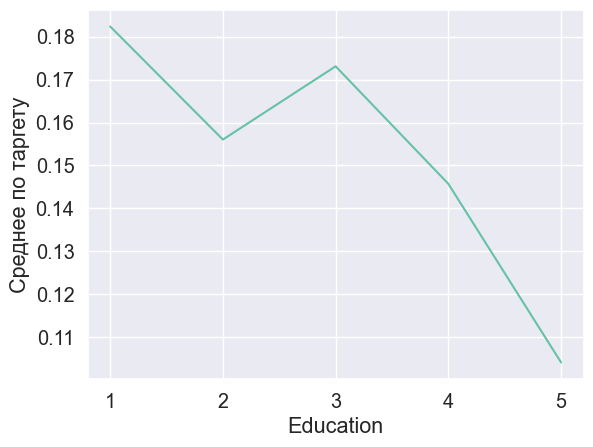

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64


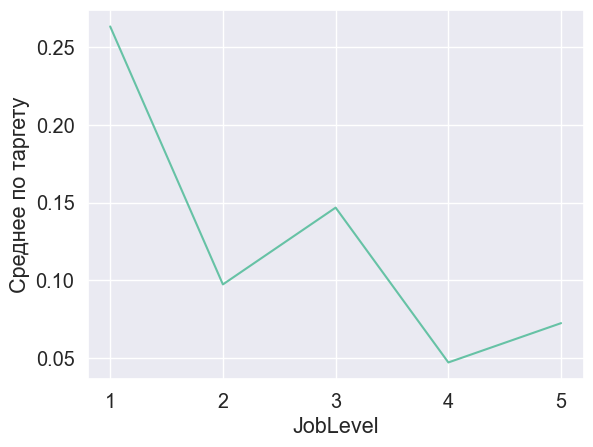

JobInvolvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64


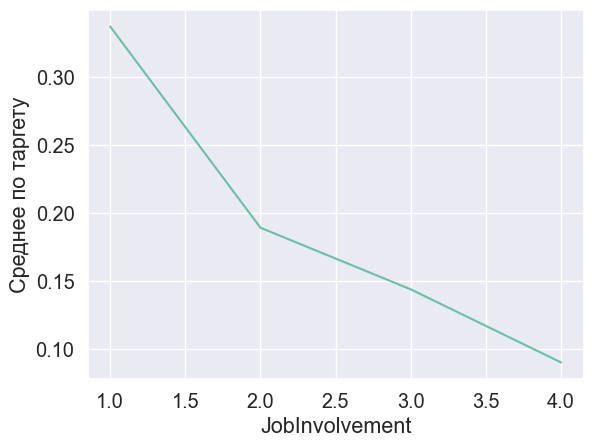

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64


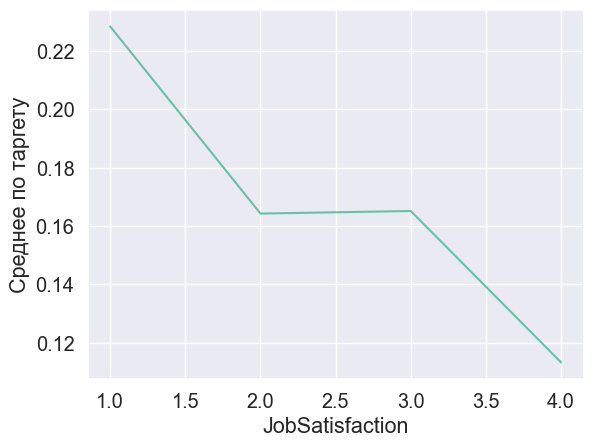

StockOptionLevel
0    631
1    596
2    158
3     85
Name: count, dtype: int64


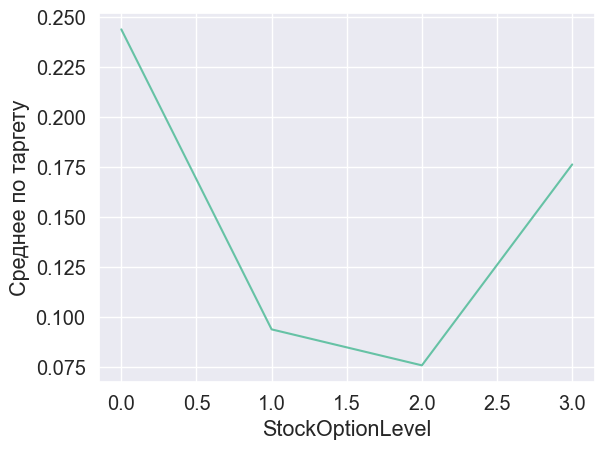

EnvironmentSatisfaction
3    453
4    446
2    287
1    284
Name: count, dtype: int64


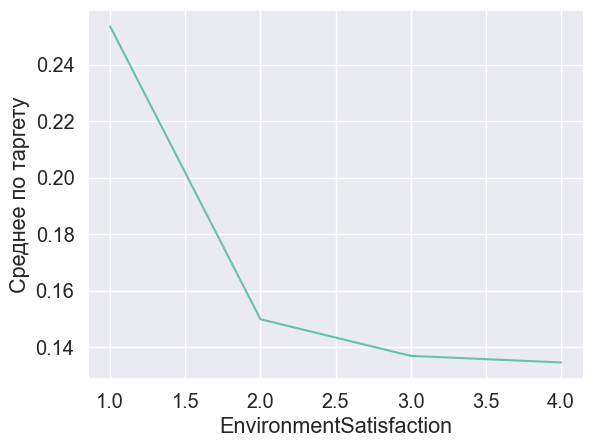

RelationshipSatisfaction
3    459
4    432
2    303
1    276
Name: count, dtype: int64


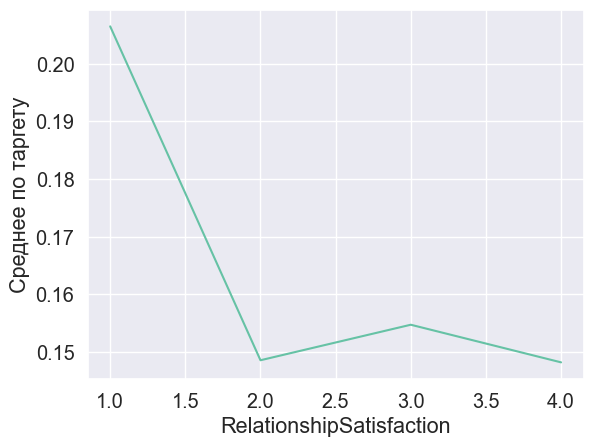

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64


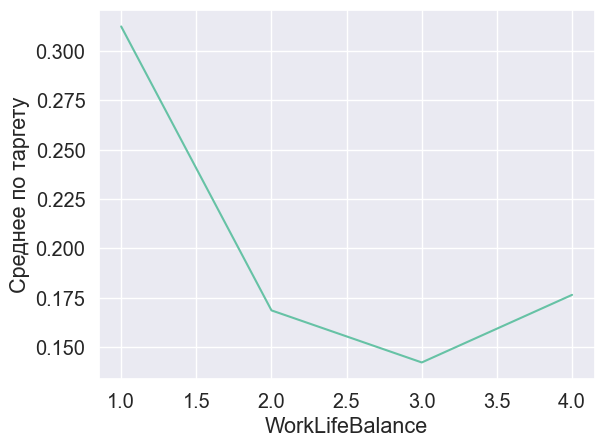

BusinessTravel
1    1043
2     277
0     150
Name: count, dtype: int64


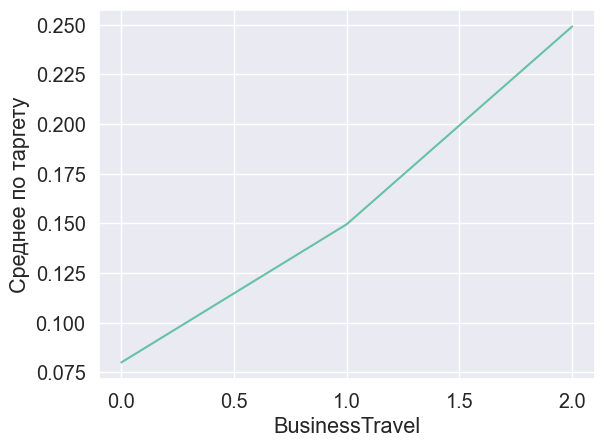

PerformanceRating
3    1244
4     226
Name: count, dtype: int64


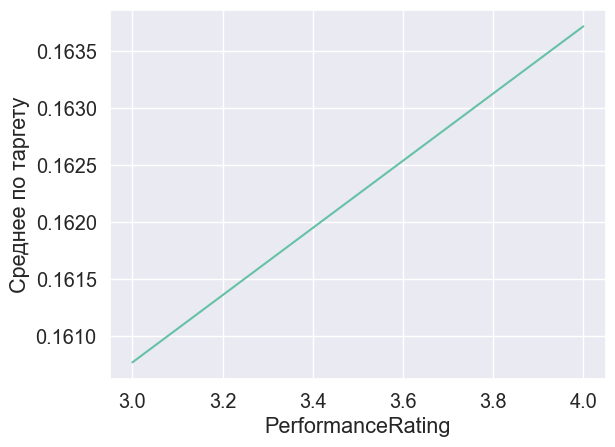

In [1060]:
travel_dict = {
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
}

X['BusinessTravel'] = X['BusinessTravel'].map(travel_dict)
X_y = X.copy()
X_y[target_column] = Y

for feature in ord_columns:
    print(X[feature].value_counts())
    target_mean = X_y.groupby(feature)[target_column].mean().reset_index().sort_values(feature)
    plt.plot(target_mean[feature], target_mean[target_column])
    plt.xlabel(feature)
    plt.ylabel('Среднее по таргету')
    plt.show()

* Признаки `Education`, `StockOptionLevel` и `JobLevel` можно закодировать с помощью One-Hot
* Признаки `JobInvolvement`, `JobSatisfaction`, `BusinessTravel` и `PerformanceRating` можно оставить в таком виде
* В признаках `EnvironmentSatisfaction`, `RelationshipSatisfaction` и `WorkLifeBalance` повышен отток только при значениях признака 1, так что можно отдельно выделить признак **1** и все остальные

In [1061]:
for feature in X.columns:
    if X[feature].dtype == 'O':
        print(feature)
        X[feature] = X[feature].apply(lambda x: x.replace(' ', '_').replace('&', 'and'))

Department
EducationField
Gender
JobRole
MaritalStatus
OverTime


In [1062]:
X[['Education', 'StockOptionLevel', 'JobLevel']] = X[['Education', 'StockOptionLevel', 'JobLevel']].astype('O')
X = pd.get_dummies(X, drop_first=True)

X['EnvironmentSatisfaction'] = X['EnvironmentSatisfaction'].apply(lambda x: 1 if x == 1 else 2)
X['RelationshipSatisfaction'] = X['RelationshipSatisfaction'].apply(lambda x: 1 if x == 1 else 2)
X['WorkLifeBalance'] = X['WorkLifeBalance'].apply(lambda x: 1 if x == 1 else 2)

X

,Age,BusinessTravel,DailyRate,DistanceFromHome,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,MonthlyRate,...,JobRole_Research_Director,JobRole_Research_Scientist,JobRole_Sales_Executive,JobRole_Sales_Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,StockOptionLevel_1,StockOptionLevel_2,StockOptionLevel_3
0,41,1,1102,1,2,94,3,4,5993,19479,...,False,False,True,False,False,True,True,False,False,False
1,49,2,279,8,2,61,2,2,5130,24907,...,False,True,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,92,2,3,2090,2396,...,False,False,False,False,False,True,True,False,False,False
3,33,2,1392,3,2,56,3,3,2909,23159,...,False,True,False,False,True,False,True,False,False,False
4,27,1,591,2,1,40,3,2,3468,16632,...,False,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,2,884,23,2,41,4,4,2571,12290,...,False,False,False,False,True,False,False,True,False,False
1466,39,1,613,6,2,42,2,1,9991,21457,...,False,False,False,False,True,False,False,True,False,False
1467,27,1,155,4,2,87,4,2,6142,5174,...,False,False,False,False,True,False,True,True,False,False
1468,49,2,1023,2,2,63,2,2,5390,13243,...,False,False,True,False,True,False,False,False,False,False


Выделим 20%, чтобы проверить качество

In [1063]:
data = X.copy()
data[target_column] = Y
data_train, data_test = train_test_split(data, test_size=0.2, random_state=42)

Данные предобработаны🎉

### 4.4. Применение логистической регрессии к данным

Применим модель и посмотрим на ее `summary`

In [1064]:
features = data_train.drop(columns=[target_column]).columns
linear = smf.logit(f"{target_column} ~{' + '.join(features)}", data_train, )
result = linear.fit()

         Current function value: 0.262689
         Iterations: 35


Проверим также, что модель не переобучилась

In [1065]:
Y_train_pred = result.predict()
Y_test_pred = result.predict(data_test)

Y_train = data_train[target_column]
Y_test = data_test[target_column]

In [1066]:
roc_auc_score(Y_train, Y_train_pred), roc_auc_score(Y_test, Y_test_pred)

(0.9035704695213898, 0.8271493212669684)

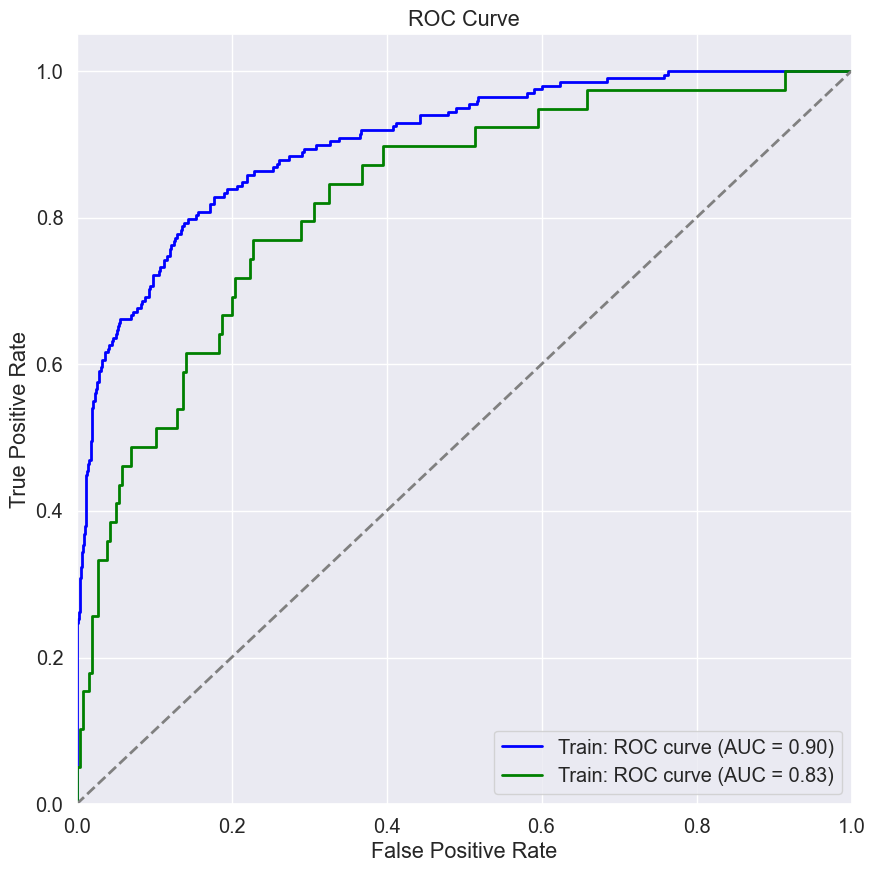

In [1067]:
# Строим ROC-кривую трейна
fpr, tpr, _ = roc_curve(Y_train, Y_train_pred)
roc_auc = roc_auc_score(Y_train, Y_train_pred)

# Строим ROC-кривую теста
fpr_test, tpr_test, _ = roc_curve(Y_test, Y_test_pred)
roc_auc_test = roc_auc_score(Y_test, Y_test_pred)

plt.figure(figsize=(10, 10))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Train: ROC curve (AUC = {roc_auc:.2f})')
plt.plot(fpr_test, tpr_test, color='green', lw=2, label=f'Train: ROC curve (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--') # линия "наугад"
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

Модель имеет неплохое качество, как на трейне, так и на тесте

**Наконец, посмотрим финально на результаты модели**

In [1068]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Attrition   No. Observations:                 1176
Model:                          Logit   Df Residuals:                     1124
Method:                           MLE   Df Model:                           51
Date:                Sun, 24 Aug 2025   Pseudo R-squ.:                  0.4205
Time:                        00:18:37   Log-Likelihood:                -308.92
converged:                      False   LL-Null:                       -533.07
Covariance Type:            nonrobust   LLR p-value:                 6.368e-65
===============================================================================================================
                                                  coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------
Intercept                                     -17.4107   4.87e+04     -0.000      1.000   -9.54e+04    9.53e+04
Department_Research_and_Development[T.True]    22.9834   4.87e+04      0.000      1.000   -9.53e+04    9.54e+04
Department_Sales[T.True]                       22.5145   4.87e+04      0.000      1.000   -9.53e+04    9.54e+04
Education_2[T.True]                             0.1471      0.388      0.379      0.705      -0.613       0.908
Education_3[T.True]                             0.2296      0.334      0.687      0.492      -0.425       0.884
Education_4[T.True]                             0.3497      0.365      0.958      0.338      -0.366       1.065
Education_5[T.True]                            -0.2356      0.797     -0.296      0.767      -1.797       1.326
EducationField_Life_Sciences[T.True]           -1.2160      0.983     -1.237      0.216      -3.143       0.711
EducationField_Marketing[T.True]               -0.8561      1.040     -0.823      0.410      -2.895       1.183
EducationField_Medical[T.True]                 -1.1331      0.976     -1.161      0.246      -3.047       0.780
EducationField_Other[T.True]                   -1.1474      1.053     -1.090      0.276      -3.211       0.916
EducationField_Technical_Degree[T.True]         0.0265      1.006      0.026      0.979      -1.946       1.999
Gender_Male[T.True]                             0.4784      0.221      2.166      0.030       0.045       0.911
JobLevel_2[T.True]                             -1.5653      0.538     -2.909      0.004      -2.620      -0.511
JobLevel_3[T.True]                              0.2993      0.846      0.354      0.724      -1.360       1.958
JobLevel_4[T.True]                             -1.3141      1.486     -0.885      0.376      -4.226       1.597
JobLevel_5[T.True]                              3.1657      2.000      1.583      0.113      -0.755       7.086
JobRole_Human_Resources[T.True]                23.8176   4.87e+04      0.000      1.000   -9.53e+04    9.54e+04
JobRole_Laboratory_Technician[T.True]           1.3476      0.739      1.823      0.068      -0.101       2.796
JobRole_Manager[T.True]                        -0.4734      1.482     -0.319      0.749      -3.379       2.432
JobRole_Manufacturing_Director[T.True]          0.7388      0.702      1.053      0.292      -0.636       2.114
JobRole_Research_Director[T.True]              -2.6664      1.501     -1.777      0.076      -5.607       0.275
JobRole_Research_Scientist[T.True]              0.0851      0.747      0.114      0.909      -1.379       1.550
JobRole_Sales_Executive[T.True]                 2.4125      1.503      1.605      0.108      -0.533       5.358
JobRole_Sales_Representative[T.True]            2.3153      1.585      1.461      0.144      -0.790       5.421
MaritalStatus_Married[T.True]                   0.4148      0.332      1.248      0.212      -0.237      

Выделим топ-10 значимых признаков

In [1069]:
result.summary2().tables[1].sort_values(by='P>|z|').head(10)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
OverTime_Yes[T.True],2.366346,0.242275,9.767208,1.556836e-22,1.891496,2.841195
NumCompaniesWorked,0.225658,0.046300,4.873819,1.094616e-06,0.134912,0.316404
BusinessTravel,1.000170,0.210386,4.753983,1.994483e-06,0.587821,1.412518
EnvironmentSatisfaction,-1.152271,0.267706,-4.304237,1.675623e-05,-1.676966,-0.627577
DistanceFromHome,0.054087,0.013151,4.112836,3.908278e-05,0.028312,0.079862
JobInvolvement,-0.561541,0.148827,-3.773102,1.612303e-04,-0.853237,-0.269845
YearsInCurrentRole,-0.213226,0.059364,-3.591833,3.283606e-04,-0.329577,-0.096874
StockOptionLevel_1[T.True],-1.243935,0.366755,-3.391736,6.945136e-04,-1.962760,-0.525109
JobSatisfaction,-0.315178,0.095978,-3.283863,1.023945e-03,-0.503292,-0.127065
YearsAtCompany,0.154210,0.048042,3.209872,1.327941e-03,0.060049,0.248372


### Вопрос в зал: какие выводы можно сделать, исходя из полученных результатов?

<br>
<details>
<br>

**Выводы для бизнеса**

* **Ключевые риски:** сверхурочные, командировки, неудобная локация офиса — факторы выгорания
* **Частая смена работы** — триггер к увольнению
* **Факторы удержания:** опционы (причем, первого уровня, как правило, достаточно), повышение вовлечённости и удовлетворённости условиями труда и самой работой
* **Неоднозначный фактор:** долгий стаж в компании может повышать риск ухода → возможно, связано с карьерным потолком или отсутствием новых возможностей

---

**Идеи по удержанию сотрудников**

1. **Снизить нагрузку от сверхурочной работы**: внедрение work-life balance программ, контроль переработок
2. **Управление командировками**: гибридные форматы встреч
3. **Географический фактор**: рассмотреть гибрид/удалёнку для сотрудников, живущих далеко
4. **Программы вовлечённости**: внерабочие мероприятия для сотрудников, развитие культуры компании
5. **Опционы и бонусные программы**: расширить участие большего числа сотрудников: так как даже первый уровень опционов дает большой прирост удержания, возможно, стоит сделать первый уровень более массовым

</details>

## 6. Итоги семинара

- подробно изучили линейную регрессию: какую задачу решаем, в чем смысл коэффициентов, как понять значимость этих коэффициентов
- на практике увидели, что у линейной регрессии есть свои ограничения
- познакомились с методами работы с ограничениями линейной регрессии: исключение и преобразование признаков, устойчивая ковариационная матрица и регуляризация
- разобрались, как можно использовать результаты линейной регрессии для улучшения продукта, сгенерировали идеи для строительного стартапа
- познакомились с логистической регрессией и применим ее на практике для изучения датасета про отток сотрудников

## 7. Полезные материалы

- [Статья про линейные модели](https://habr.com/ru/companies/ods/articles/323890/)